In [ ]:
from models.padim import PaDiM
import torch

backbone = "dinov2_vits14_reg"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = PaDiM(backbone_name=backbone, embed_dim=100)
model_path = f"/home/localuser/Documents/tmp/padim/weights/{backbone}_bottle.pt"
state_dict = torch.load(model_path)
model.idx = state_dict["idx"]
mean = state_dict["mean"]
cov_inv = state_dict["cov_inv"]
model.eval()
model = model.to(device)

/home/localuser/Documents/tmp/padim/.venv/lib/python3.11/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/localuser/Documents/tmp/padim/.venv/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [2]:
from PIL import Image
from torchvision import transforms
path = "/home/localuser/data/mvtec/bottle/test/broken_large/000.png"

img = Image.open(path).convert("RGB")
transform = transforms.Compose([
    transforms.Resize((672, 672)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])
tensor = transform(img).unsqueeze(0).to(device)
with torch.no_grad():
    features = model(tensor)

In [3]:
malanobis_distance = model.mahalanobis_distance(features, mean, cov_inv)

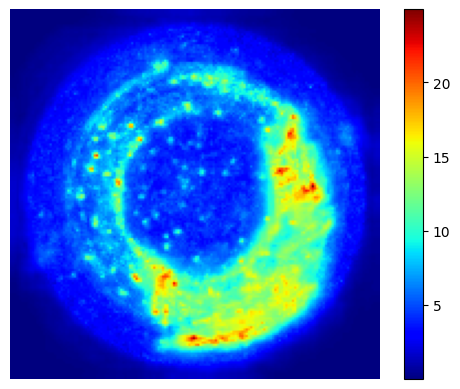

In [6]:
import matplotlib.pyplot as plt
plt.imshow(malanobis_distance.cpu().numpy()[0], cmap='jet')
plt.colorbar()
plt.axis('off')
plt.show()